# NutriWise — Data EDA: receipts & auxiliary datasets

**Purpose.** Ground-truth the numbers we quote about our data, and decide *what each
dataset is (and is not) good for* before we invest in labeling.

Three datasets are examined:

| # | File | Role |
|---|------|------|
| ① | `receipts/NutriWise_receipts.xlsx` | **The crown jewel** — real German receipt lines that drive food matching |
| ② | `receipts/Groceries_dataset.xlsx` | Transaction log — fuel for a *future* consumption / next-cart feature |
| ③ | `receipts/Instacart Market Basket Analysis_Products.xlsx` | English product catalog — auxiliary / mostly out of scope |

**Honesty note.** None of these is *training* data for a model. The matcher runs at
inference (rules + off-the-shelf embeddings). ① is unlabeled real queries — turning it
into a labeled gold-set is the next work item.

---
## Setup — paths, imports, house style

In [1]:
from pathlib import Path
import zipfile, io
from xml.etree.ElementTree import iterparse
import pandas as pd
import matplotlib.pyplot as plt

# Paths relative to the repo root (notebook lives in ml/)
REPO = Path.cwd().parent if Path.cwd().name == "ml" else Path.cwd()
RECEIPTS = REPO / "receipts"
NUTRIWISE = RECEIPTS / "NutriWise_receipts.xlsx"
GROCERIES = RECEIPTS / "Groceries_dataset.xlsx"
INSTACART = RECEIPTS / "Instacart Market Basket Analysis_Products.xlsx"
BLS_XLSX  = REPO / "BLS_data" / "BLS_4_0_Daten_2025_DE.xlsx"

for p in (NUTRIWISE, GROCERIES, INSTACART, BLS_XLSX):
    assert p.exists(), f"Missing data file: {p}"
print("Repo:", REPO)
print("All 4 data files found.")

# NutriWise corporate design: one accent (sage green), lots of whitespace, sans-serif
SAGE, SOFT, INK, INK_SOFT = "#7c9a6a", "#eef2ea", "#1d1d21", "#6e6f74"
plt.rcParams.update({"font.family": "sans-serif", "axes.edgecolor": INK_SOFT})

def hbar(labels, values, title, xlabel, highlight_max=True, fmt=None, figsize=(8, 4)):
    """On-brand horizontal bar chart: sage accent, no top/right spines."""
    fig, ax = plt.subplots(figsize=figsize)
    order = list(values)
    top = max(order) if order else 0
    colors = [SAGE if (highlight_max and v == top) else SOFT for v in values]
    bars = ax.barh(labels, values, color=colors, edgecolor=SAGE, linewidth=1)
    pad = (max(values) if values else 1) * 0.01
    for bar, v in zip(bars, values):
        txt = fmt(v) if fmt else f"{v:,}"
        ax.text(v + pad, bar.get_y() + bar.get_height()/2, txt,
                va="center", ha="left", color=INK, fontsize=9)
    ax.set_xlabel(xlabel, color=INK_SOFT)
    ax.set_title(title, color=INK, pad=12, loc="left")
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    ax.tick_params(colors=INK_SOFT)
    plt.tight_layout()
    plt.show()

Repo: /Users/jenniferrake/Desktop/GitHub_Bootcamp/LLM
All 4 data files found.


---
## ① NutriWise receipts — the crown jewel

Real receipts, manually transcribed. Header note: a title row sits above the real
header, so we read the `items` sheet with `header=2`.

In [2]:
items = pd.read_excel(NUTRIWISE, sheet_name="items", header=2)
print(f"items sheet: {items.shape[0]} rows x {items.shape[1]} cols")
print("columns:", list(items.columns))
n_receipts = items["receipt-ID"].nunique()
n_uncertain = int(items["uncertain"].sum())
print(f"\nDistinct receipts : {n_receipts}")
print(f"Distinct stores   : {items['store'].nunique()}")
print(f"Uncertain flags   : {n_uncertain}/{len(items)} = {n_uncertain/len(items):.0%}")
items.head(6)

items sheet: 180 rows x 10 cols
columns: ['receipt-ID', 'store', 'location', 'date', 'name_original', 'name_standard', 'quantity', 'category', 'uncertain', 'notes']

Distinct receipts : 27
Distinct stores   : 7
Uncertain flags   : 15/180 = 8%


,receipt-ID,store,location,date,name_original,name_standard,quantity,category,uncertain,notes
0,1,REWE,"Erich-Ollenhauer-Str., 30851 Langenhagen",2026-06-17,LINSEN MIT SG,Linsen mit Spätzle und Saitenwürstchen (Fertig...,1,prepared_meal,True,'SG' mehrdeutig; wahrscheinlich schwäbisches L...
1,2,REWE,"Skalitzer Str. 134, 10999 Berlin",2026-07-15,SALATGURKE,Salatgurke,1,vegetable,False,NaN
2,2,REWE,"Skalitzer Str. 134, 10999 Berlin",2026-07-15,CHILI MIX TRI.,Chili-Mix Tricolore,1,vegetable,True,'TRI.' als Tricolore gedeutet.
3,3,LIDL,"Oranienplatz 4, 10999 Berlin",2025-12-10,Auberginen,Auberginen,1,vegetable,False,NaN
4,3,LIDL,"Oranienplatz 4, 10999 Berlin",2025-12-10,Kartoffeln Süß,Süßkartoffeln,1,vegetable,False,NaN
5,3,LIDL,"Oranienplatz 4, 10999 Berlin",2025-12-10,Bananen Fairtra.,Bananen (Fairtrade),1,fruit,False,NaN


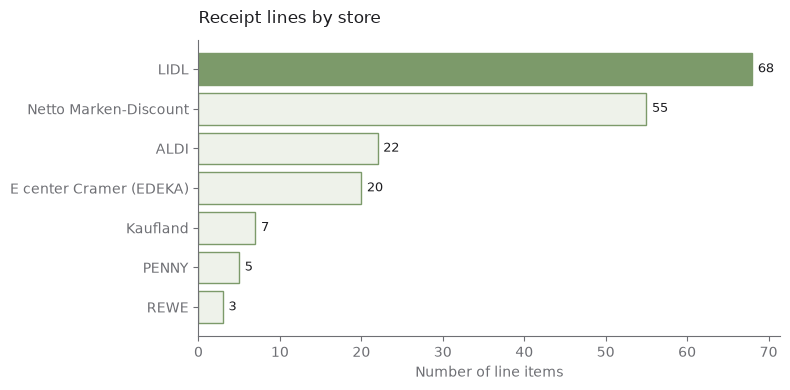

In [3]:
# Store (retail chain) distribution — 7 German discounters/supermarkets
vc = items["store"].value_counts().sort_values()
hbar(vc.index.tolist(), vc.values.tolist(),
     "Receipt lines by store", "Number of line items", fmt=lambda v: f"{int(v)}")

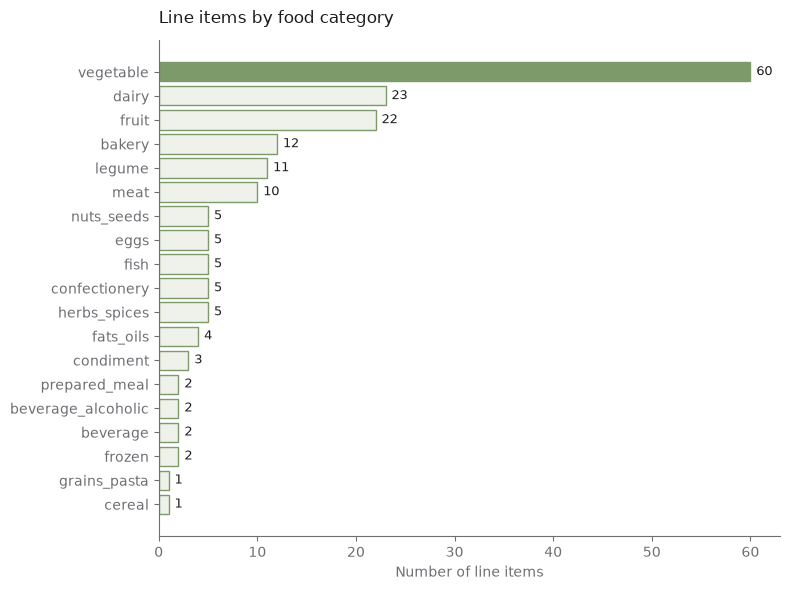

In [4]:
# Food category distribution (German class labels, as transcribed)
vc = items["category"].value_counts().sort_values()
hbar(vc.index.tolist(), vc.values.tolist(),
     "Line items by food category", "Number of line items",
     fmt=lambda v: f"{int(v)}", figsize=(8, 6))

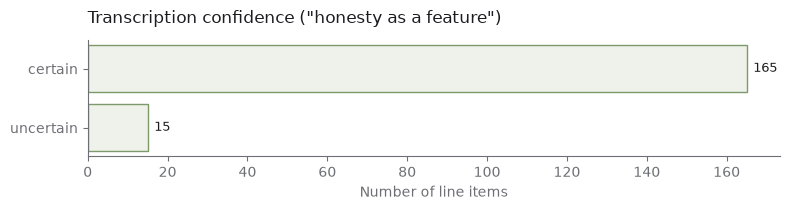

Examples flagged uncertain:
  'LINSEN MIT SG'              -> 'Linsen mit Spätzle und Saitenwürstchen (Fertiggericht)'
  'CHILI MIX TRI.'             -> 'Chili-Mix Tricolore'
  'Bulgur Rote Beete'          -> 'Bulgur mit Roter Bete (Fertigprodukt)'
  'G&G Tomaten g'              -> 'Gut&Günstig Tomaten (gestückelt, Dose)'
  "Tony's Great.Bits"          -> "Tony's Chocolonely Schokolade"


In [5]:
# Honesty flag: how many line items are we unsure about?
certain = len(items) - n_uncertain
hbar(["uncertain", "certain"], [n_uncertain, certain],
     "Transcription confidence (\"honesty as a feature\")", "Number of line items",
     highlight_max=False, fmt=lambda v: f"{int(v)}", figsize=(8, 2.2))
print("Examples flagged uncertain:")
for _, r in items[items["uncertain"]].head(5).iterrows():
    print(f"  {r['name_original']!r:28} -> {r['name_standard']!r}")

---
## The matching challenge — raw vs. cleaned, and the BLS gap

Every receipt line exists in two forms:

- `name_original` — the **raw** line as printed (what OCR really sees)
- `name_standard` — a **cleaned** human interpretation

The matcher must map these to a BLS-4.0 food entry. The critical fact: **almost none of
our cleaned names appear verbatim in the BLS corpus** — so exact lookup is useless and
fuzzy/semantic matching is unavoidable. This is *why* we need a labeled gold-set.

In [6]:
# How much does cleanup change the string?
differs = (items["name_original"].astype(str).str.strip()
           != items["name_standard"].astype(str).str.strip()).sum()
print(f"name_original != name_standard : {differs}/{len(items)} = {differs/len(items):.0%}")
print("\nRaw -> cleaned examples:")
for _, r in items.head(8).iterrows():
    print(f"  {str(r['name_original'])!r:26} -> {str(r['name_standard'])!r}")

name_original != name_standard : 142/180 = 79%

Raw -> cleaned examples:
  'LINSEN MIT SG'            -> 'Linsen mit Spätzle und Saitenwürstchen (Fertiggericht)'
  'SALATGURKE'               -> 'Salatgurke'
  'CHILI MIX TRI.'           -> 'Chili-Mix Tricolore'
  'Auberginen'               -> 'Auberginen'
  'Kartoffeln Süß'           -> 'Süßkartoffeln'
  'Bananen Fairtra.'         -> 'Bananen (Fairtrade)'
  'Avocado vorger.'          -> 'Avocado (vorgereift)'
  'Zitronen Bio'             -> 'Bio-Zitronen'


In [7]:
# BLS corpus overlap: how many cleaned names sit EXACTLY in the BLS table?
bls = pd.read_excel(BLS_XLSX)
NAME_COL = "Lebensmittelbezeichnung"
corpus = (bls[NAME_COL].dropna().astype(str).str.strip())
corpus = corpus[corpus != ""].drop_duplicates()
corpus_set = set(corpus)
corpus_set_lower = {c.lower() for c in corpus_set}
print(f"BLS corpus: {len(corpus_set):,} unique food names")

std = items["name_standard"].astype(str).str.strip()
exact  = std.isin(corpus_set).sum()
casei  = std.str.lower().isin(corpus_set_lower).sum()
print(f"\nname_standard found EXACTLY in BLS : {exact}/{len(items)} = {exact/len(items):.1%}")
print(f"name_standard found (case-insensitive): {casei}/{len(items)}")
print("\n=> Exact lookup is a dead end. 180 real queries, 0 usable labels yet.")

BLS corpus: 7,140 unique food names

name_standard found EXACTLY in BLS : 1/180 = 0.6%
name_standard found (case-insensitive): 1/180

=> Exact lookup is a dead end. 180 real queries, 0 usable labels yet.


---
## ② Groceries dataset — a transaction log (not for matching)

Member number + date + one **generic English category** per row. No product text, no BLS
anchor. **Verdict:** useless for name matching; well suited to a *future* consumption /
next-cart prediction module (reorder intervals, "you're low on X").

In [8]:
groc = pd.read_excel(GROCERIES, sheet_name=0)
print(f"shape: {groc.shape}  columns: {list(groc.columns)}")
print(f"members        : {groc['Member_number'].nunique():,}")
print(f"distinct labels: {groc['itemDescription'].nunique()}")
print(f"date range     : {pd.to_datetime(groc['Date']).min().date()} -> "
      f"{pd.to_datetime(groc['Date']).max().date()}")
groc.head(5)

shape: (38765, 3)  columns: ['Member_number', 'Date', 'itemDescription']
members        : 3,898
distinct labels: 167
date range     : 2014-01-01 -> 2015-12-30


,Member_number,Date,itemDescription
0,1808,2015-07-21,tropical fruit
1,2552,2015-01-05,whole milk
2,2300,2015-09-19,pip fruit
3,1187,2015-12-12,other vegetables
4,3037,2015-02-01,whole milk


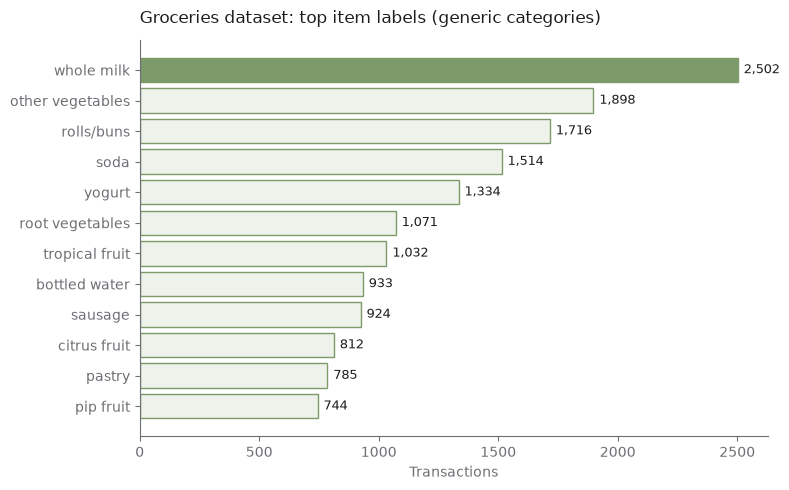

Use for -> consumption / next-cart prediction (ML block 2, later).
Not for  -> receipt-line matching (no product text, no BLS link).


In [9]:
vc = groc["itemDescription"].value_counts().head(12).sort_values()
hbar(vc.index.tolist(), vc.values.tolist(),
     "Groceries dataset: top item labels (generic categories)",
     "Transactions", fmt=lambda v: f"{int(v):,}", figsize=(8, 5))
print("Use for -> consumption / next-cart prediction (ML block 2, later).")
print("Not for  -> receipt-line matching (no product text, no BLS link).")

---
## ③ Instacart products — English catalog (mostly out of scope)

~50k English product names + aisle/department **ids**. No baskets, no receipt lines, no
BLS anchor and no ground truth. Documented here so the "we considered it" decision is on
record.

*Technical note:* this file is saved as **strict OOXML**, which `openpyxl` cannot open, so
we parse the sheet XML directly.

In [10]:
def load_strict_xlsx(path):
    """Minimal reader for strict-OOXML .xlsx (openpyxl fails on these)."""
    z = zipfile.ZipFile(path)
    ss = []
    for _, el in iterparse(io.BytesIO(z.read("xl/sharedStrings.xml"))):
        if el.tag.split("}")[-1] == "si":
            ss.append("".join(t.text or "" for t in el.iter()
                              if t.tag.split("}")[-1] == "t"))
            el.clear()
    rows = []
    for _, el in iterparse(io.BytesIO(z.read("xl/worksheets/sheet1.xml"))):
        if el.tag.split("}")[-1] == "row":
            vals = []
            for c in el:
                t, v = c.get("t"), None
                for ch in c:
                    if ch.tag.split("}")[-1] == "v":
                        v = ch.text
                vals.append(ss[int(v)] if (t == "s" and v is not None) else v)
            rows.append(vals)
            el.clear()
    return pd.DataFrame(rows[1:], columns=rows[0])

prod = load_strict_xlsx(INSTACART)
print(f"shape: {prod.shape}  columns: {list(prod.columns)}")
prod.head(5)

shape: (49688, 4)  columns: ['product_id', 'product_name', 'aisle_id', 'department_id']


,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


In [11]:
print(f"distinct product names: {prod['product_name'].nunique():,}")
print("Use for -> at best a synonym/alias lexicon or distractor corpus.")
print("Not for -> matching (no BLS anchor) or training (no labels, no baskets).")

distinct product names: 49,684
Use for -> at best a synonym/alias lexicon or distractor corpus.
Not for -> matching (no BLS anchor) or training (no labels, no baskets).


---
## Export — pipeline artifact for Step 2

The `.xlsx` stays the single human source of truth. Here we derive a machine-readable
`receipts/receipts_queries.json` (one record per line item) that mirrors the gold-set
schema. `gold_*` fields start empty and get filled during labeling — kept JSON so every
label change is git-diffable.

In [12]:
import json
import math

def clean(v):
    """NaN/NaT -> None; Timestamp -> ISO date; numpy scalars -> python."""
    if v is None:
        return None
    if isinstance(v, float) and math.isnan(v):
        return None
    if isinstance(v, pd.Timestamp):
        return v.date().isoformat()
    if hasattr(v, "item"):
        return v.item()
    return v

records = []
for _, r in items.iterrows():
    records.append({
        "receipt_id":     clean(r["receipt-ID"]),
        "store":          clean(r["store"]),
        "date":           clean(r["date"]),
        "name_original":  clean(r["name_original"]),
        "name_standard":  clean(r["name_standard"]),
        "category":       clean(r["category"]),
        "uncertain":      bool(r["uncertain"]),
        "notes":          clean(r["notes"]),
        # --- to be filled during Step 2 labeling ---
        "gold_bls_name":   None,
        "gold_corpus_idx": None,
        "label_source":    None,
    })

OUT = RECEIPTS / "receipts_queries.json"
with open(OUT, "w", encoding="utf-8") as f:
    json.dump(records, f, ensure_ascii=False, indent=2)

print(f"Wrote {len(records)} records -> {OUT.relative_to(REPO)}")
print("Sample record:")
print(json.dumps(records[3], ensure_ascii=False, indent=2))

Wrote 180 records -> receipts/receipts_queries.json
Sample record:
{
  "receipt_id": 3,
  "store": "LIDL",
  "date": "2025-12-10",
  "name_original": "Auberginen",
  "name_standard": "Auberginen",
  "category": "vegetable",
  "uncertain": false,
  "notes": null,
  "gold_bls_name": null,
  "gold_corpus_idx": null,
  "label_source": null
}


---
## Summary & handoff to gold-set extension

| Dataset | Trains the LLM? | Primary role |
|---|---|---|
| ① NutriWise receipts | ❌ (unlabeled) | **Core** — 180 real queries -> extend matching gold-set 45 → ~180 |
| ② Groceries | ❌ | Fuel for consumption / next-cart feature (later) |
| ③ Instacart | ❌ | Auxiliary lexicon / documented dead-end |

**Key facts confirmed on real data:**
- 180 line items · 7 stores · ~27 receipts · 15/180 flagged uncertain.
- `name_original` vs `name_standard` differ for the large majority of lines → cleanup matters.
- Effectively **0/180** cleaned names sit verbatim in the BLS corpus → exact lookup fails;
  fuzzy + semantic matching is mandatory, and every label must be earned.

**Next (Step 2):** feed the 180 queries (both `name_original` and `name_standard`) through
the existing hybrid ranker to propose BLS matches, verify labels independently, report an
honest label-error rate, and keep the extended set **separate** from the real 45.